In [1]:
# 1. Install newest unsloth version - Hide Warnings

!pip install unsloth
!pip uninstall unsloth -y && pip install --upgrade --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git

import warnings; warnings.filterwarnings("ignore")
from datasets.utils.logging import disable_progress_bar; disable_progress_bar()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 23.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 81.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 101.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 85.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 81.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.6 MB/s eta 0:0

In [2]:
# 2. Configuration

from kaggle_secrets import UserSecretsClient

MODEL_NAME     = "unsloth/Llama-3.2-1B-bnb-4bit"
MAX_SEQ_LENGTH = 2048   # corpus chunk size
GITHUB_REPO    = "https://github.com/tillacs/Domain-Adapted-LLM-Training-for-Automotive-E-E.git"
HF_REPO        = "tillacs/ee-cpt-llama"
HF_TOKEN       = UserSecretsClient().get_secret("HF_TOKEN")
SEED           = 42

In [3]:
# 3. Load compressed Model

from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = True,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.3: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.03G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

Unsloth: Will load unsloth/Llama-3.2-1B-bnb-4bit as a legacy tokenizer.


In [4]:
# 4. Part1 Training Data + Data Mixing

import json
import random
from datasets import Dataset, load_dataset

!git clone -q {GITHUB_REPO} repo


# 4a. Decode token IDs from Part1 back to text, append EOS

def load_texts(path):
    with open(path) as f:
        ids = json.load(f)
    return [t + tokenizer.eos_token for t in tokenizer.batch_decode(ids, skip_special_tokens=True)]

train_texts = load_texts("repo/part1_data/data_corpus/train.json")
val_dataset = Dataset.from_dict({"text": load_texts("repo/part1_data/data_corpus/val.json")})


# 4b. Data Mixing with WikiText

wiki   = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
n_wiki = max(1, int(len(train_texts) * 0.05))
wiki_texts = [t + tokenizer.eos_token for t in wiki["text"] if len(t.strip()) > 100][:n_wiki]

random.seed(SEED)
all_texts = train_texts + wiki_texts
random.shuffle(all_texts)

dataset = Dataset.from_dict({"text": all_texts}) # build HugginFace dataset-object

print(f"Domain: {len(train_texts)} | General: {len(wiki_texts)} | Total: {len(dataset)} | Val: {len(val_dataset)}")

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Domain: 442 | General: 22 | Total: 464 | Val: 50


In [13]:
# 5. Pre-CPT Inference

PROMPTS = [
    "The AUTOSAR software architecture consists of",
    "The Controller Area Network (CAN) bus protocol",
    "ISO 26262 defines functional safety requirements for",
]

@torch.no_grad()
def perplexity():
    loss, n = 0.0, 0
    for ex in val_dataset:
        ids = tokenizer(ex["text"], return_tensors="pt", truncation=True,
                        max_length=MAX_SEQ_LENGTH).input_ids.to("cuda")
        loss += model(ids, labels=ids).loss.item() * ids.shape[1]; n += ids.shape[1]
    return math.exp(loss / n)

@torch.no_grad()
def show_samples():
    for p in PROMPTS:
        out = model.generate(**tokenizer(p, return_tensors="pt").to("cuda"),
                             max_new_tokens=150, do_sample=False)  # greedy
        print(f"\n{p}\n{tokenizer.decode(out[0], skip_special_tokens=True)}")
    

FastLanguageModel.for_inference(model) # Switch to inference mode
model.eval()
print(f"Pre-CPT PPL: {perplexity():.2f}")
show_samples()
FastLanguageModel.for_training(model) # Switch back to training mode before LoRA setup and training

Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Pre-CPT PPL: 10.27


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



The AUTOSAR software architecture consists of
The AUTOSAR software architecture consists of a set of software components that are used to implement the AUTOSAR specification. The components are organized into layers, which are further divided into sub-layers. The layers are described in the following sections.
The AUTOSAR software architecture consists of a set of software components that are used to implement the AUTOSAR specification. The components are organized into layers, which are further divided into sub-layers. The layers are described in the following sections.
The AUTOSAR software architecture consists of a set of software components that are used to implement the AUTOSAR specification. The components are organized into layers, which are further divided into sub-layers. The layers are described in the following sections.


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



The Controller Area Network (CAN) bus protocol
The Controller Area Network (CAN) bus protocol is a serial bus protocol that is used in automotive and industrial applications. It is a high-speed serial bus that is used to transmit data between devices. The CAN bus protocol is used in a variety of applications, including automotive, industrial, and military. The CAN bus protocol is a serial bus that is used to transmit data between devices. The CAN bus protocol is used in a variety of applications, including automotive, industrial, and military. The CAN bus protocol is a serial bus that is used to transmit data between devices. The CAN bus protocol is used in a variety of applications, including automotive, industrial, and military. The CAN bus protocol is a serial bus that is used to transmit data between devices. The CAN bus protocol is used in a variety

ISO 26262 defines functional safety requirements for
ISO 26262 defines functional safety requirements for the automotive industry. 

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048, padding_idx=128004)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear4bit(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): Llam

In [21]:
# 6. LoRA Setup

model = FastLanguageModel.get_peft_model(
    model,
    r                          = 64,
    lora_alpha                 = 32,
    lora_dropout               = 0,
    target_modules             = ["q_proj", "k_proj", "v_proj", "o_proj",
                                  "gate_proj", "up_proj", "down_proj",
                                  "embed_tokens", "lm_head"],
    use_rslora                 = True, # scaling α/√r → stable across different r
    use_gradient_checkpointing = "unsloth",
    random_state               = SEED,
)

TypeError: Unsloth: Your model already has LoRA adapters. Your new parameters are different.

In [15]:
# 7. Training

from unsloth import UnslothTrainer, UnslothTrainingArguments, is_bfloat16_supported

trainer = UnslothTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = dataset,
    eval_dataset       = val_dataset,
    dataset_text_field = "text",
    max_seq_length     = MAX_SEQ_LENGTH,
    args = UnslothTrainingArguments(
        output_dir                  = "/kaggle/working/cpt_output",
        num_train_epochs            = 2,
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 2, # effective batch = 8
        learning_rate               = 1e-4,
        embedding_learning_rate     = 1e-5,
        lr_scheduler_type           = "cosine",
        warmup_steps                = 6,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        optim                       = "adamw_8bit",
        logging_steps               = 1,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,  # keep the best val-loss checkpoint
        metric_for_best_model       = "eval_loss",
        greater_is_better           = False,
        seed                        = SEED,
    ),
)

stats = trainer.train()

print(f"Post-CPT PPL: {math.exp(trainer.state.best_metric):.2f} | {stats.metrics['train_runtime']/60:.1f} min")

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 464 | Num Epochs = 2 | Total steps = 116
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 316,096,512 of 1,814,579,200 (17.42% trained)


Unsloth: Setting lr = 1.00e-05 instead of 1.00e-04 for embed_tokens.
Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Epoch,Training Loss,Validation Loss
1,2.310488,2.189969
2,2.007094,2.188965


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/cpt_output/checkpoint-58/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/cpt_output/checkpoint-116/tokenizer_config.json.


Post-CPT PPL: 8.93 | 15.3 min


In [16]:
# 8. Post-CPT Inference

print("── Post-CPT samples ──")
FastLanguageModel.for_inference(model) # Switch to inference mode
model.eval()
show_samples()

Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


── Post-CPT samples ──


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



The AUTOSAR software architecture consists of
The AUTOSAR software architecture consists of three layers: the application layer, the middleware layer, and the hardware layer. The application layer is responsible for the application software, which is developed by the application developer. The middleware layer provides the communication infrastructure between the application software and the hardware platform. It includes the AUTOSAR communication layer, which is responsible for the communication between the application software and the AUTOSAR platform. The hardware layer is responsible for the hardware platform, which includes the processor, memory, and I/O devices.
The AUTOSAR software architecture is designed to support the development of automotive software systems. It provides a standardized and flexible software architecture that can be used in different automotive applications. The AUTOSAR software architecture is based on the ISO 26262 standard, which is


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



The Controller Area Network (CAN) bus protocol
The Controller Area Network (CAN) bus protocol is a standard for connecting electronic control units (ECUs) in a distributed automotive system. It is a synchronous, message-based, bus protocol that supports communication between multiple devices. The CAN bus is commonly used in modern vehicles, including those with advanced driver-assistance systems (ADAS) and autonomous driving capabilities. The CAN bus is designed to provide low-latency, reliable, and efficient communication between ECUs, allowing for seamless data exchange and real-time control. The protocol is based on the CAN bus standard, which was developed by the SAE International in 1983. The CAN bus is a multi-master protocol, meaning that multiple ECUs can transmit messages simultaneously, but only one message can be transmitted at a time. This ensures that messages are

ISO 26262 defines functional safety requirements for
ISO 26262 defines functional safety requirements for th

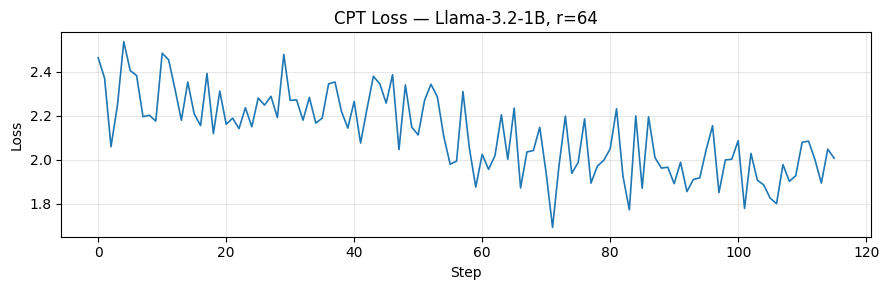

In [17]:
# 9. Loss Curve

import matplotlib.pyplot as plt
losses = [x["loss"] for x in trainer.state.log_history if "loss" in x]
plt.figure(figsize=(9, 3))
plt.plot(losses, lw=1.2); plt.xlabel("Step"); plt.ylabel("Loss")
plt.title("CPT Loss — Llama-3.2-1B, r=64"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [19]:
## 10. Push merged Model to HuggingFace Hub for Part3

model.push_to_hub_merged(
    HF_REPO,
    tokenizer,
    save_method = "merged_16bit",
    token       = HF_TOKEN,
)
print(f"Pushed: https://huggingface.co/{HF_REPO}")

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

Unsloth: Merging weights into 16bit:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:31<00:00, 31.15s/it]


Unsloth: Merge process complete. Saved to `/kaggle/working/tillacs/ee-cpt-llama`
Pushed: https://huggingface.co/tillacs/ee-cpt-llama
